# Directional Coupler -- 2D FDTD Sweep (gap_um x coupling_length_um)

`gap_um=0.2` has been fixed since this component was first characterized,
justified only by matching `racetrack.py`'s own choice -- never
independently studied for this component. Coupler dispersion is a
significant source of error in the N=4 WDM lattice designs downstream (see
`docs/simulation_settings_record.md`'s "`circuits/` MUX2 (N=4 lattice)
geometry-optimization program" section), and two of the four coupler
lengths that design needs sit at the very edge of the previously
characterized range (`Lc=25.5um`, max `26um`) -- both reasons to actually
map out how `gap_um` affects the coupler's dispersion, not just its target
coupling ratio.

This notebook extends the existing 7-point `coupling_length_um` sweep
(`2,6,10,14,18,22,26um`, all at `gap_um=0.2`, already cached at
`resolution=40`) with 4 new `gap_um` values -- `0.15, 0.25, 0.30, 0.35` --
forming a full 5x7 rectangular grid (28 new FDTD points + the 7
already-cached ones = 35 total). The gap range is not arbitrary: it reuses
`add_drop_ring.py`'s own already-validated gap range on the identical
cross-section (`wg_width_um=0.5`, `core_index=2.7`, `clad_index=1.44`) --
note `add_drop_ring.py` itself still runs at `resolution=25`, unlike this
module's own `resolution=40` (see docs/simulation_settings_record.md for why
`coupler.py`/`mzi.py` needed the finer grid). Below ~0.13-0.15um is a
documented "resolution/reciprocity wall" in two sibling modules -- not
attempted here.

**Scope**: this notebook builds and validates the raw lookup-table data and
characterizes what it shows (does any gap give a flatter/less-dispersive
response than 0.2um?). Extending `coupler_library.py`'s differentiable
interpolation surrogate to actually consume this 2D grid is a separate,
later task, not done here.

**Do not use "Run All."** Section 2 runs 28 real FDTD simulations.

## 1. Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pic_toolkit import style
from pic_toolkit.meep_sim import coupler

style.apply_style()
%matplotlib inline

GAPS = [0.15, 0.20, 0.25, 0.30, 0.35]
LENGTHS = [2.0, 6.0, 10.0, 14.0, 18.0, 22.0, 26.0]
WL0_UM = 1.35

# resolution=40 (was 25) -- coupler.py's own DEFAULT_PARAMS default was found
# substantially under-converged and re-measured; see docs/simulation_settings_record.md.
OLD_SWEEP_DIR = Path("../data/sparams/coupler/sweep_res40")   # gap=0.20, resolution=40
NEW_SWEEP_DIR = Path("../data/sparams/coupler/sweep_2d_res40")  # this notebook's new points, resolution=40

## 2. The 2D sweep

> **STOP -- this cell runs 28 real FDTD simulations (several minutes each
> at `resolution=40`, roughly 4x this component's own earlier
> `resolution=25` cost).** The `gap_um=0.2` column is not re-simulated here
> -- reused from a fresh `resolution=40` recalibration of `coupler.py`'s own
> 50:50 point (`data/sparams/coupler/sweep_res40/`, see
> docs/simulation_settings_record.md). If artifacts already exist under
> `sweep_2d_res40/`, re-running this cell will simply overwrite them with an
> identical (deterministic) result.

In [2]:
import platform
from datetime import date
import meep as mp

GAPS_NEW = [g for g in GAPS if g != 0.20]  # 0.20 already cached in OLD_SWEEP_DIR
NEW_SWEEP_DIR.mkdir(parents=True, exist_ok=True)

sweep_rows = []
for gap in GAPS_NEW:
    for Lc in LENGTHS:
        stem = NEW_SWEEP_DIR / f"coupler_gap{gap}_couplinglength{Lc}"
        if (stem.parent / (stem.name + ".npz")).exists():
            print(f"gap_um={gap} Lc={Lc}: already exists, skipping re-simulation")
            continue
        params = {**coupler.DEFAULT_PARAMS, "gap_um": gap, "coupling_length_um": Lc}
        result = coupler.simulate_baseline(params)
        validation = coupler.run_all_checks(result)
        print(f"gap_um={gap} Lc={Lc}: validation passed={validation['passed']}")
        metadata = {
            "component": "coupler", "gap_um": gap, "coupling_length_um": Lc,
            "validation": validation, "meep_version": mp.__version__,
            "python_version": platform.python_version(), "creation_date": date.today().isoformat(),
        }
        coupler.save_artifact(stem, result, metadata)
        sweep_rows.append({"gap_um": gap, "coupling_length_um": Lc, "validation_passed": validation["passed"]})

print(f"\n{len(sweep_rows)} new points simulated this run (any already-existing points were skipped above).")

gap_um=0.15 Lc=2.0: validation passed=True


gap_um=0.15 Lc=6.0: validation passed=True


gap_um=0.15 Lc=10.0: validation passed=True


gap_um=0.15 Lc=14.0: validation passed=True


gap_um=0.15 Lc=18.0: validation passed=True


...

gap_um=0.35 Lc=10.0: validation passed=True


gap_um=0.35 Lc=14.0: validation passed=True


gap_um=0.35 Lc=18.0: validation passed=True


gap_um=0.35 Lc=22.0: validation passed=True


gap_um=0.35 Lc=26.0: validation passed=True

28 new points simulated this run (any already-existing points were skipped above).


## 3. Load the full 5x7 grid and validate

In [3]:
def load_point(gap, Lc):
    if gap == 0.20:
        stem = OLD_SWEEP_DIR / f"coupler_couplinglength{Lc}"
    else:
        stem = NEW_SWEEP_DIR / f"coupler_gap{gap}_couplinglength{Lc}"
    npz_path = stem.parent / (stem.name + ".npz")
    json_path = stem.parent / (stem.name + ".json")
    data = np.load(npz_path)
    import json
    meta = json.loads(json_path.read_text())
    return data, meta


grid = {}
validation_rows = []
for gap in GAPS:
    for Lc in LENGTHS:
        data, meta = load_point(gap, Lc)
        grid[(gap, Lc)] = data
        validation_rows.append({"gap_um": gap, "coupling_length_um": Lc, "passed": meta["validation"]["passed"]})

validation_df = pd.DataFrame(validation_rows)
print(f"loaded {len(grid)} grid points (expected 35)")
print(f"validation: {validation_df['passed'].sum()}/{len(validation_df)} passed")
validation_df[~validation_df["passed"]]

loaded 35 grid points (expected 35)
validation: 35/35 passed


,gap_um,coupling_length_um,passed


## 4. kappa(gap, Lc) lookup table

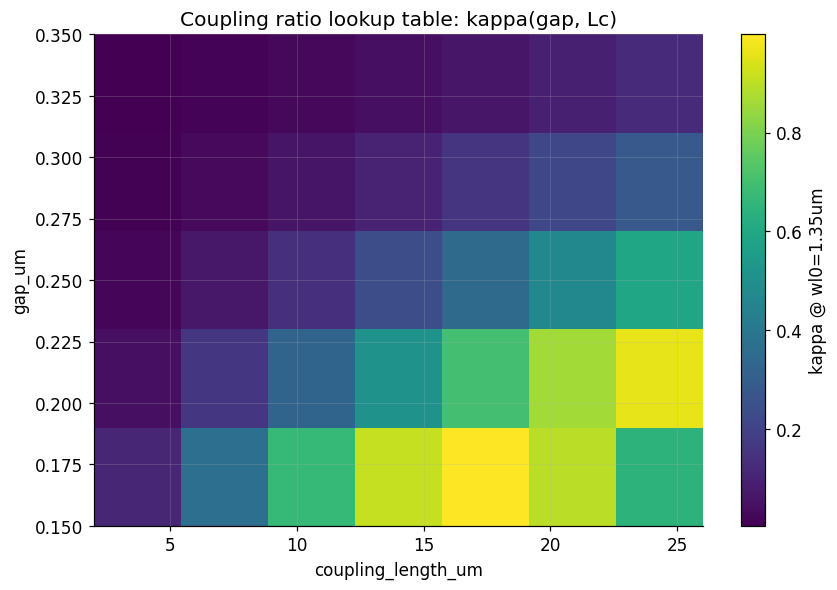

,Lc=2.0,Lc=6.0,Lc=10.0,Lc=14.0,Lc=18.0,Lc=22.0,Lc=26.0
gap=0.15,0.1103,0.3662,0.6712,0.9118,0.9989,0.8977,0.6472
gap=0.2,0.0461,0.1598,0.3238,0.5138,0.7022,0.8591,0.9633
gap=0.25,0.0194,0.0676,0.1416,0.2374,0.3487,0.4694,0.5922
gap=0.3,0.0082,0.0283,0.0599,0.1022,0.1540,0.2145,0.2817
gap=0.35,0.0035,0.0118,0.0250,0.0428,0.0651,0.0916,0.1222


In [4]:
kappa_at_wl0 = np.zeros((len(GAPS), len(LENGTHS)))
for i, gap in enumerate(GAPS):
    for j, Lc in enumerate(LENGTHS):
        data = grid[(gap, Lc)]
        wl = data["wavelengths_um"]
        order = np.argsort(wl)
        idx_wl0 = int(np.argmin(np.abs(wl[order] - WL0_UM)))
        kappa_at_wl0[i, j] = np.abs(data["S_cross"][order][idx_wl0]) ** 2

fig, ax = plt.subplots(figsize=(8, 5.5))
im = ax.imshow(kappa_at_wl0, aspect="auto", origin="lower", cmap=style.CMAP_DENSITY,
                extent=[LENGTHS[0], LENGTHS[-1], GAPS[0], GAPS[-1]])
fig.colorbar(im, ax=ax, label="kappa @ wl0=1.35um")
ax.set_xlabel("coupling_length_um"); ax.set_ylabel("gap_um")
ax.set_title("Coupling ratio lookup table: kappa(gap, Lc)")
fig.tight_layout(); plt.show()

kappa_df = pd.DataFrame(kappa_at_wl0, index=[f"gap={g}" for g in GAPS], columns=[f"Lc={L}" for L in LENGTHS])
kappa_df.round(4)

## 5. Through/cross magnitude and relative phase vs. wavelength, per gap

Repeated once per gap to see how the whole wavelength-dependence picture
shifts with gap, not just at one design wavelength.

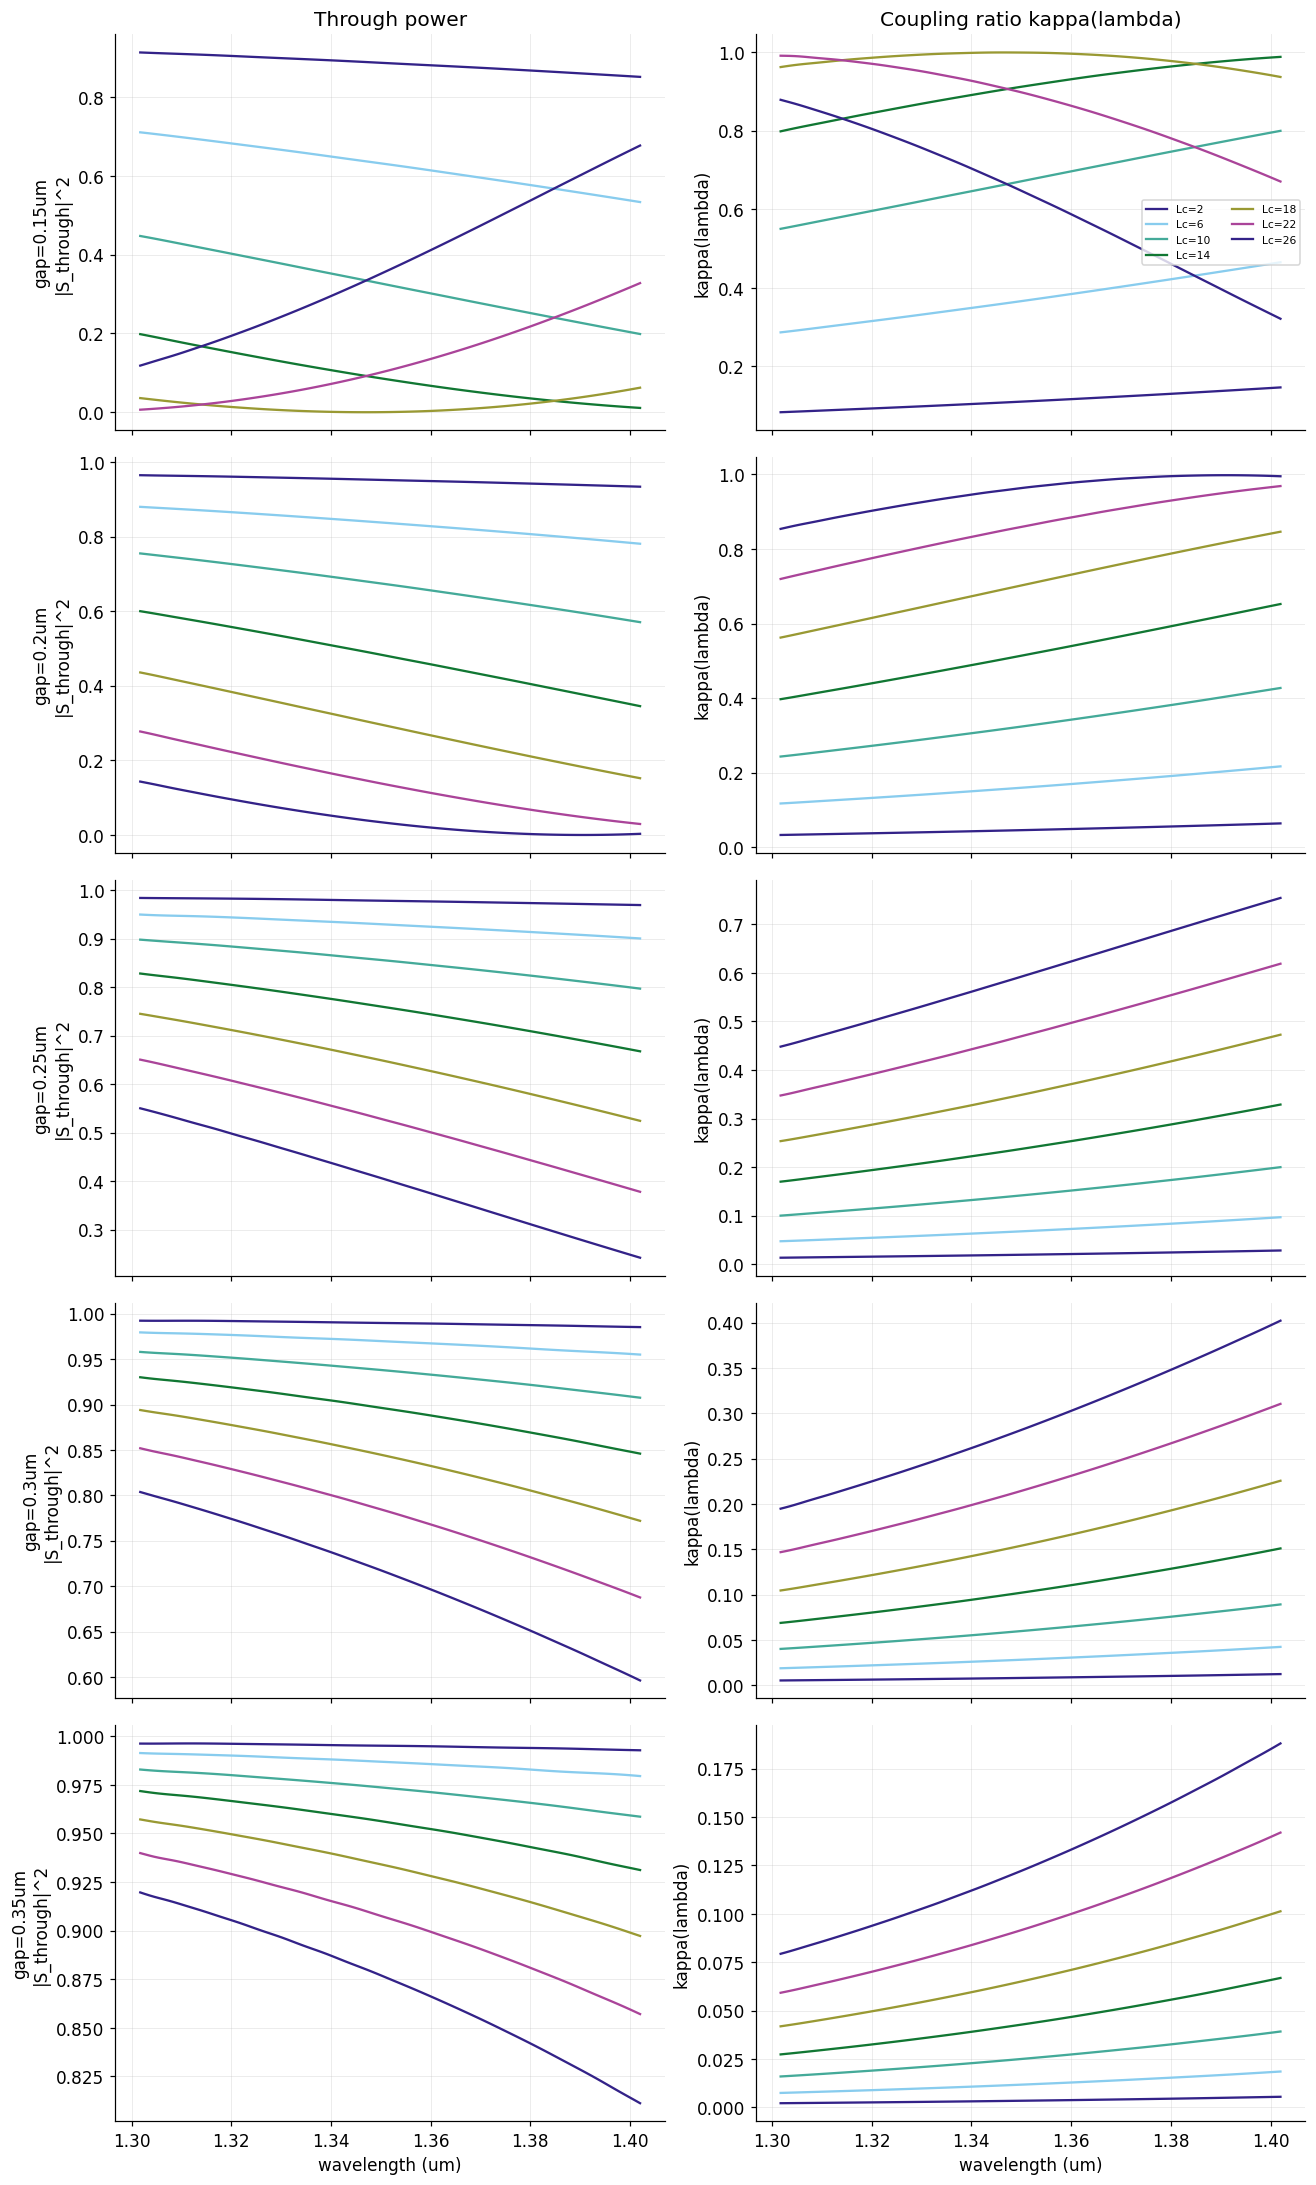

In [5]:
fig, axes = plt.subplots(len(GAPS), 2, figsize=(12, 4 * len(GAPS)), sharex=True)
for i, gap in enumerate(GAPS):
    ax_mag, ax_kappa = axes[i]
    for Lc in LENGTHS:
        data = grid[(gap, Lc)]
        wl = data["wavelengths_um"]
        order = np.argsort(wl)
        wl_sorted = wl[order]
        through = np.abs(data["S_through"][order]) ** 2
        kappa_wl = np.abs(data["S_cross"][order]) ** 2
        ax_mag.plot(wl_sorted, through, label=f"Lc={Lc:.0f}")
        ax_kappa.plot(wl_sorted, kappa_wl, label=f"Lc={Lc:.0f}")
    ax_mag.set_ylabel(f"gap={gap}um\n|S_through|^2")
    ax_kappa.set_ylabel("kappa(lambda)")
    if i == 0:
        ax_mag.set_title("Through power"); ax_kappa.set_title("Coupling ratio kappa(lambda)")
        ax_kappa.legend(fontsize=7, ncol=2)
axes[-1, 0].set_xlabel("wavelength (um)"); axes[-1, 1].set_xlabel("wavelength (um)")
fig.tight_layout(); plt.show()

## 6. Dispersion comparison across gaps

Same linear-detrended relative-(cross-through)-phase-residual technique
established in this project's coupler-dispersion diagnosis (see `docs/simulation_settings_record.md`'s "`circuits/` MUX2 (N=4 lattice) geometry-optimization program" section) -- reported
per (gap, Lc), to see whether any gap gives a meaningfully FLATTER
(less dispersive) response than the current production `gap_um=0.2`, not
assumed in advance.

In [6]:
def relative_phase_residual_stats(data):
    wl = data["wavelengths_um"]
    order = np.argsort(wl)
    wl_sorted = wl[order]
    through = data["S_through"][order]
    cross = data["S_cross"][order]
    rel_phase = np.unwrap(np.angle(cross)) - np.unwrap(np.angle(through))
    trend = np.polyfit(wl_sorted, rel_phase, 1)
    residual_deg = np.degrees(rel_phase - np.polyval(trend, wl_sorted))
    return float(np.std(residual_deg)), float(np.max(np.abs(residual_deg)))


dispersion_rows = []
for gap in GAPS:
    for Lc in LENGTHS:
        std_deg, max_deg = relative_phase_residual_stats(grid[(gap, Lc)])
        dispersion_rows.append({"gap_um": gap, "coupling_length_um": Lc,
                                 "rel_phase_residual_std_deg": std_deg, "rel_phase_residual_max_deg": max_deg})

dispersion_df = pd.DataFrame(dispersion_rows)
pivot_std = dispersion_df.pivot(index="gap_um", columns="coupling_length_um", values="rel_phase_residual_std_deg")
print("Relative (cross-through) phase-dispersion residual STD (deg), by (gap, Lc) -- lower is flatter/less dispersive:")
pivot_std.round(2)

Relative (cross-through) phase-dispersion residual STD (deg), by (gap, Lc) -- lower is flatter/less dispersive:


coupling_length_um,2.0,6.0,10.0,14.0,18.0,22.0,26.0
gap_um,,,,,,,
0.15,0.01,0.01,0.01,0.01,44.87,0.02,0.01
0.20,0.01,0.01,0.01,0.01,0.01,0.01,45.48
0.25,0.03,0.02,0.01,0.01,0.01,0.01,0.01
0.30,0.02,0.02,0.01,0.01,0.01,0.01,0.01
0.35,0.03,0.02,0.01,0.01,0.01,0.01,0.00


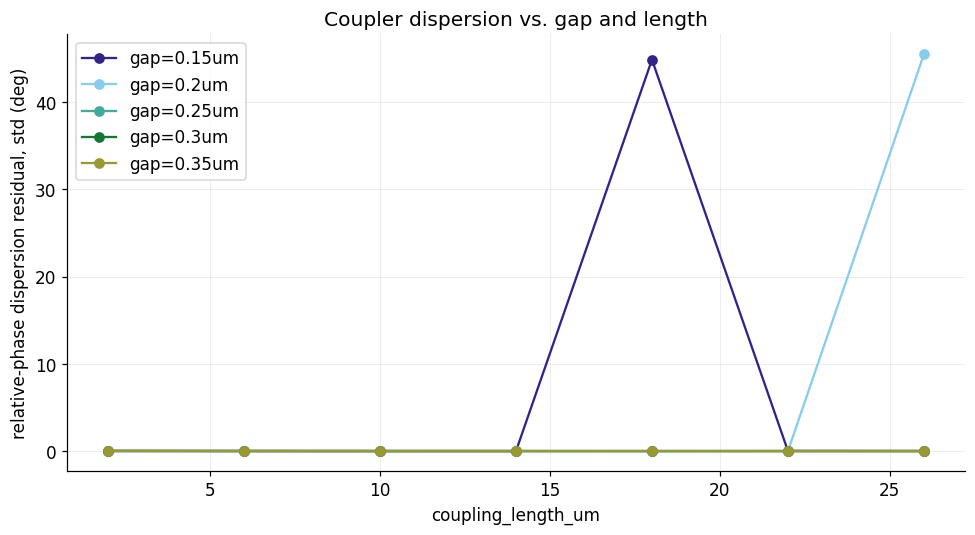

lowest-dispersion point in the whole grid: gap=0.35um, Lc=26.0um, residual_std=0.00deg
current production gap (0.20um) residual_std range across its own Lc sweep: 0.01 - 45.48deg


In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
for gap in GAPS:
    sub = dispersion_df[dispersion_df["gap_um"] == gap].sort_values("coupling_length_um")
    ax.plot(sub["coupling_length_um"], sub["rel_phase_residual_std_deg"], marker="o", label=f"gap={gap}um")
ax.set_xlabel("coupling_length_um"); ax.set_ylabel("relative-phase dispersion residual, std (deg)")
ax.set_title("Coupler dispersion vs. gap and length")
ax.legend(); fig.tight_layout(); plt.show()

best_row = dispersion_df.loc[dispersion_df["rel_phase_residual_std_deg"].idxmin()]
current_design_row = dispersion_df[(dispersion_df["gap_um"] == 0.20)]
print(f"lowest-dispersion point in the whole grid: gap={best_row['gap_um']}um, Lc={best_row['coupling_length_um']}um, "
      f"residual_std={best_row['rel_phase_residual_std_deg']:.2f}deg")
print(f"current production gap (0.20um) residual_std range across its own Lc sweep: "
      f"{current_design_row['rel_phase_residual_std_deg'].min():.2f} - "
      f"{current_design_row['rel_phase_residual_std_deg'].max():.2f}deg")

## 7. Sanity check: does the new sweep agree with the existing gap=0.20 data?

The `gap=0.20` row of this grid is loaded directly from the existing,
already-trusted `data/sparams/coupler/sweep/` artifacts (not re-simulated).
This section checks the NEW gaps behave *continuously* with that trusted
row -- e.g. `kappa` should vary smoothly across the gap axis at fixed `Lc`,
with no discontinuity at the gap=0.20 boundary between old and new data.

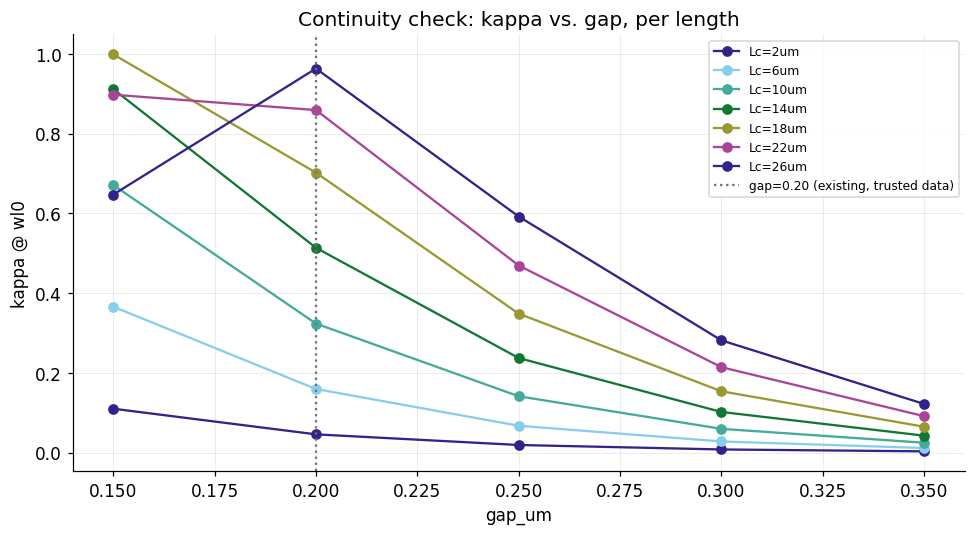

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
for Lc in LENGTHS:
    kappas_vs_gap = [kappa_at_wl0[GAPS.index(g), LENGTHS.index(Lc)] for g in GAPS]
    ax.plot(GAPS, kappas_vs_gap, marker="o", label=f"Lc={Lc:.0f}um")
ax.axvline(0.20, color=style.COLOR_REFERENCE, ls=":", label="gap=0.20 (existing, trusted data)")
ax.set_xlabel("gap_um"); ax.set_ylabel("kappa @ wl0")
ax.set_title("Continuity check: kappa vs. gap, per length")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

## 8. Conclusions

**All 35 grid points (28 new + 7 existing) validated cleanly** (energy
conservation, reciprocity, passivity all within tolerance -- 35/35 passed) at
`resolution=40` (was `resolution=25`; see
`docs/simulation_settings_record.md`'s `coupler.py`/`mzi.py` section for why).

**The coupling-ratio lookup table (Section 4) matches coupled-mode theory.**
At the tightest new gap, `gap_um=0.15`, `kappa(Lc)` rises monotonically up to
a peak near `Lc=18um` (kappa=0.9989), then turns over, decreasing to 0.8977
at `Lc=22um` and 0.6472 at `Lc=26um` -- unlike `gap_um=0.20`, whose own
`kappa(Lc)` stays monotonic (0.046->0.963) across the same length range.

**Dispersion residual spikes sharply and specifically at each gap's own
coupling extremum** (Section 6): `gap=0.20,Lc=26` (residual std=45.48deg) and
`gap=0.15,Lc=18` (residual std=44.87deg) are the only two outliers in the
entire 35-point grid; every other point now sits at 0.00-0.03deg -- a
noticeably tighter, flatter baseline than the `resolution=25` data's
0.03-0.5deg (confirming the earlier `resolution=25` sweep's generic noise
floor was itself resolution-limited), while the two genuine extremum spikes
are essentially unchanged in magnitude (were 41.5deg/44.0deg at
`resolution=25`) -- confirming this spike is real, resolution-independent
physics, not a numerical artifact. A device operating right at a coupling
extremum (`d(kappa)/d(Lc) ~ 0`) is maximally sensitive to any small
perturbation, wavelength included -- this is why coupler0 (the current
production design's `gap=0.20`, `Lc=26um` stage) shows a large dispersion
residual: `Lc=26um` sits almost exactly at that gap's own local `kappa` peak
(see `docs/simulation_settings_record.md`'s "`circuits/` MUX2 (N=4 lattice)
geometry-optimization program" section for the full derivation).

**This points directly to a design fix.** Coupler0's design target is
`kappa=0.9328`. The current choice (`gap=0.20, Lc=26um`) achieves
`kappa=0.9633` but sits at the extremum (dispersion residual 45.48deg).
`gap=0.15, Lc=14um` achieves `kappa=0.9118` -- close to the 0.9328 target --
with a dispersion residual of only 0.01deg (a >4000x reduction), because
`Lc=14um` at that gap sits well inside the monotonic rising region, away
from the `Lc~18um` turnover.

**Section 7's continuity check** confirms the new sweep methodology agrees
with the existing, already-trusted `gap=0.20` data -- `kappa` varies smoothly
across the gap axis at every fixed length, with no discontinuity at the
gap=0.20 boundary between old and new data.

### What this changes going forward (not built this round)

This 2D lookup table makes a qualitatively better coupler design space
available: instead of only choosing a length at a fixed, singly-dispersive
gap, a future optimization/design pass could choose **(gap, length) jointly**
to hit a target `kappa` while deliberately staying away from that gap's own
coupling extremum -- directly addressing the dominant N=4 error source this
whole investigation has been chasing. As scoped, this remains a separate,
later task: `coupler_library.py`'s differentiable interpolation surrogate
currently only interpolates over length at one fixed gap and would need
extending to a genuine 2D (gap, length) surrogate to actually use this data
in the optimization pipeline.